Implementation Details:
We first load the defined custom KS functions and standard libraries.
Then we sample for each sample size $n$, we generate two independent sets, $P$ and $Q$, from a standard normal distribution $N(0, 1)$. Eventually, we compute the maximum distance between the two empirical distribution functions

In [32]:
include("C:/Users/Odysseus/GR6104_Homework/HW2/src/ks-stat.jl")
using Statistics, Plots, Random

function if_convergence(tt_steps, iterations=200)
    ks_means = []

    for n in tt_steps
        current_ks = []
        for _ in 1:iterations
            P_set = randn(n)
            Q_set = randn(n)
            s_val = ks_func(P_set, (t) -> empi_df(Q_set, t))
            push!(current_ks, s_val)
        end
        
    push!(ks_means, mean(current_ks))
    println("Sample size n = $n, average KS statistic: $(round(ks_means[end], digits=4))")
    end
    return ks_means
end


if_convergence (generic function with 2 methods)

Sample size n = 50, average KS statistic: 0.1656
Sample size n = 100, average KS statistic: 0.1179
Sample size n = 200, average KS statistic: 0.0817
Sample size n = 400, average KS statistic: 0.0611
Sample size n = 800, average KS statistic: 0.0424
Sample size n = 1600, average KS statistic: 0.0294
Sample size n = 3200, average KS statistic: 0.021


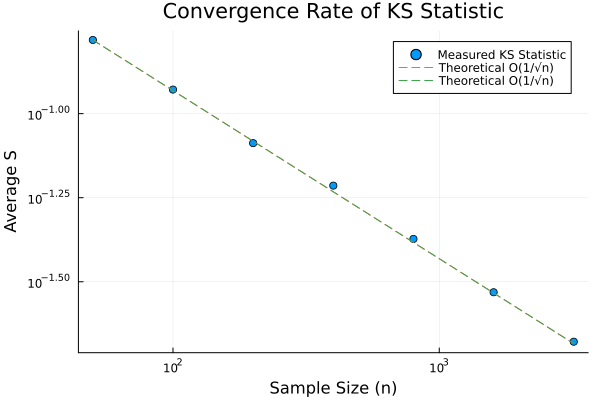

In [ ]:
Random.seed!(123)

test_n = [50,100,200,400,800,1600,3200]
avg_stats = if_convergence(test_n)


theoretical = Float64[]
const_C = avg_stats[1]*sqrt(test_n[1])

for n in test_n
    val = const_C / sqrt(n)
    push!(theoretical, val)
end
plot!(test_n, theoretical, label="Theoretical O(1/√n)", linestyle=:dash)

display(p)


The log-log plot shows a clear linear relationship with a slope of approximately $-0.5$. 
This confirms that the empirical convergence rate of the two-same-sample KS statistic is indeed $O(1/\sqrt{n})$.

We have evidence to show that we implemented the KS statistic correctly.